# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback



## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [24]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [25]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
    { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress:  50%|█████     | 1/2 [00:00<00:00,  7.84it/s]

Successfully downloaded: airline-safety.csv


Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00,  6.57it/s]

Successfully downloaded: bad-drivers.csv


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [26]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [27]:
#pip install pingouin

In [28]:
import pandas as pd
import numpy as np
from scipy import stats
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import sys
sys.path.append('./modules')
from scipy import stats
from IPython.display import display

In [29]:
data = pd.read_csv('data/02-processed/nhis_2024_sample_adult_cleaned.csv')
data.head()

,HHX,WTFA_A,PSTRAT,PPSU,AGEP_A,sex,race_ethnicity,race_group,education,POVRATTC_A,health_insurance,housing_tenure,usual_place_care,transportation_barrier,housing_cost_trouble,general_health,government_rent_assistance,delayed_medical_care,any_er_visit,doctor_gap_yr
0,H067658,5780.565,122,2,49,Male,White non-Hispanic,White only,AA academic,2.82,Uninsured,Owned or being bought,No single usual place,0.0,0.0,5.0,-1.0,0.0,0.0,5.0
1,H076577,3994.244,122,2,53,Male,White non-Hispanic,White only,AA academic,2.01,Insured,Rented,Has usual place of care,1.0,0.0,4.0,0.0,0.0,2.0,1.0
2,H019335,6636.755,122,2,82,Male,White non-Hispanic,White only,AA academic,1.90,Insured,Rented,Has usual place of care,0.0,0.0,4.0,0.0,0.0,0.0,1.0
3,H012701,13767.420,122,2,42,Male,White non-Hispanic,White only,"Some college, no degree",4.48,Insured,Owned or being bought,Has usual place of care,0.0,0.0,3.0,-1.0,0.0,0.0,2.0
4,H049678,18880.030,115,1,38,Female,Black non-Hispanic,Black only,Professional,6.37,Insured,Rented,Has usual place of care,0.0,0.0,3.0,0.0,0.0,1.0,1.0


We use Chi_square (categorical predictor vs. categorical outcomes) and Mann Whitney U test (categorical/biniary predictor vs. ordinal outcomes) to evaluate the effect of housing_tenure on 5 dependent variables. The housing_tenure columns contain a category of ‘Other arrangement', which is a vague definition, so we drop rows with 'Other arrangement' when analyze this specific independent variable.

In [30]:
def chi_square(predictor,outcome,d):
    contingency=pd.crosstab(d[predictor],d[outcome])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    w = np.sqrt(chi2 / n)
    print(predictor,'---',outcome)
    display(contingency)
    print('Chi square statistics: ',chi2)
    print('p_value: ', p_value)
    print('degree of freedom: ', dof)
    print('Cohen W: ', w)
    print('\n')



def mann_whitney(predictor, group1_name, group2_name, outcome, d):
    group1 = d[d[predictor] == group1_name][outcome].dropna()
    group2 = d[d[predictor] == group2_name][outcome].dropna()
    u_stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
    rank_biserial = 1 - (2 * u_stat) / (len(group1) * len(group2))
    
    print(predictor, '---', outcome)
    display(pd.DataFrame({
        'group_1': [group1_name],
        'group_2': [group2_name],
        'U-val': [u_stat],
        'p-val': [p_value],
        'RBC': [rank_biserial],
        'group_1_median': [group1.median()],
        'group_2_median': [group2.median()]
    }))


# Binary & Categorical Outcomes (Chi-Square)
def chi_sq(data, pred, out):
    print(f"--- Testing Association with: {out} ---")
    contingency_table = pd.crosstab(data[pred], data[out])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
        
    print(f"Chi-Square Statistic: {chi2:.4f}")
    print(f"p-value: {p_val:.4e}")
    if p_val < 0.05:
        print("Result: Statistically Significant (p < 0.05). The distributions differ between groups.\n")
    else:
        print("Result: Not Statistically Significant. No strong evidence of a difference.\n")

    # test effect size
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1  
    
    # Cramér's V — works for any table size
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    print(f"\nEffect Size:")
    print(f"  Cramér's V: {cramers_v:.4f}")
    print(f"\nCramér's V interpretation (Cohen's benchmarks):")
    if   cramers_v < 0.10: label = "negligible"
    elif cramers_v < 0.20: label = "small"
    elif cramers_v < 0.40: label = "medium"
    else:                  label = "large"
    print(f"  → {label} effect")


# Count & Ordinal Outcomes (Mann-Whitney U)
def mwu(data, pred, out):
    # Split dataset into the two comparison groups 
    group_yes = data[data[pred] == 1] 
    group_no = data[data[pred] == 0]  
    
    print(f"--- Testing Differences in: {out} ---")
    # Run Mann-Whitney U test (non-parametric, handles skew and ordinal ranks perfectly)
    u_stat, p_val = stats.mannwhitneyu(group_yes[out], group_no[out], alternative='two-sided')
        
    print(f"U Statistic: {u_stat:.4e}")
    print(f"p-value: {p_val:.4e}")
    if p_val < 0.05:
        print(f"Result: Statistically Significant (p < 0.05). The rank distributions of {out} differ.\n")
    else:
        print("Result: Not Statistically Significant. No strong evidence of a shift.\n")

    #test effect size
    n1, n2 = len(group_yes[out]), len(group_no[out])
    r = 1 - (2 * u_stat) / (n1 * n2)
    print(f"Group '1': n={n1}, median={group_yes[out].median():.1f}, mean={group_yes[out].mean():.2f}")
    print(f"Group '0': n={n2}, median={group_no[out].median():.1f}, mean={group_no[out].mean():.2f}")
    print(f"\nEffect Size:")
    print(f"  Rank-biserial r: {r:.4e}")

    # Cohen's benchmarks adapted for r
    abs_r = abs(r)
    if   abs_r < 0.10: label = "negligible"
    elif abs_r < 0.30: label = "small"
    elif abs_r < 0.50: label = "medium"
    else:              label = "large"
    print(f"  → {label} effect")
    print(f"\nInterpretation: r = {r:.3f} means the '1' group tends to")
    print(f"  rank {'higher' if r > 0 else 'lower'} on {out} than '0'")

data_drop_other=data[data['housing_tenure']!='Other arrangement']

Bar graphs are generated to compare the difference between proportion of people who have usual place of care and proportion of people who have delayed_medical care among house renters and owners. The Chi-square test with p-value close to 0 and a cohen w of 0.13 demonstrate that housing tenure probably has a small significant effect on whether the person has a usual place of care or not. According to the plot and Chi-square statistics, the proportion of house owners have usual place of care is larger than that of renters, so house owners are more likely to get a stable and continuous medical care. However, with p-value approaching 0 but a cohen w value less than 0.1 of the Chi-square test for housing_tenure's effect on delayed_medical_care, we can conclude that the medical care for renters are more likely to be delayed while the effect is so small so that it's negligible.
Stacked bar graphs are generated to compare the difference in distribution of number of er visits, number of gap years between visiting docore, and general health score among house owners and renters. Mann Whitney U test shows that the effect of housing tenure on the distributions are all significant since p-values approaches 0. According to graphs, renters visit er more often than house owners, which means they may fail to access continuous and standard health care, leading to more frequent health emergencies than non-renters; renters' gap years between visiting docotors are also averagely longer than housing owners; renters general health score is lower than house owners. However, the RBC scores for the 3 MWU tests are all smaller than 0.1, which means the difference in distributions are so small that can be negligible.

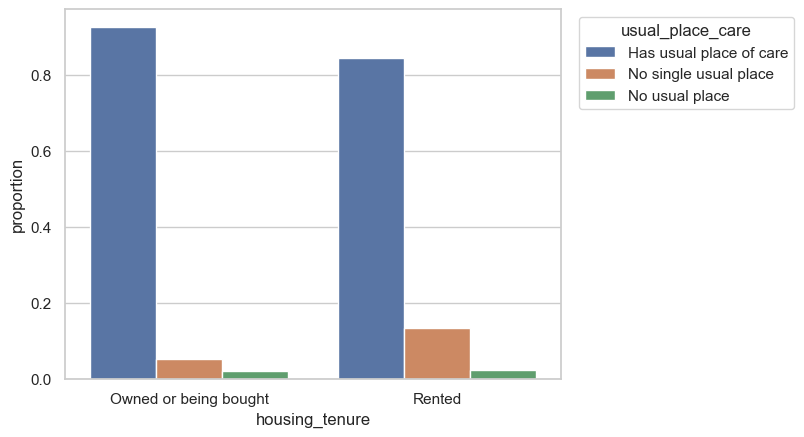

In [31]:
prop_df=data_drop_other.groupby('housing_tenure').usual_place_care.value_counts(normalize=True).rename('proportion').reset_index()
tenure_usual_plot=sns.barplot(data=prop_df,x='housing_tenure',y='proportion',hue='usual_place_care')
tenure_usual_plot.legend(
    title='usual_place_care',
    bbox_to_anchor=(1.02, 1)
)

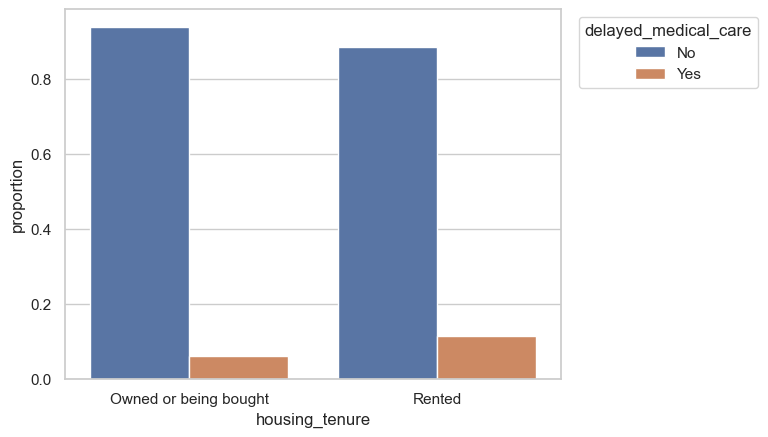

In [35]:
prop_df=data_drop_other.groupby('housing_tenure').delayed_medical_care.value_counts(normalize=True).rename('proportion').reset_index()
prop_df['delayed_medical_care'] = (prop_df['delayed_medical_care'].map({0: 'No', 1: 'Yes'}))
tenure_delayed_plot=sns.barplot(data=prop_df,x='housing_tenure',y='proportion',hue='delayed_medical_care')
tenure_delayed_plot.legend(
    title='delayed_medical_care',
    bbox_to_anchor=(1.02, 1)
)

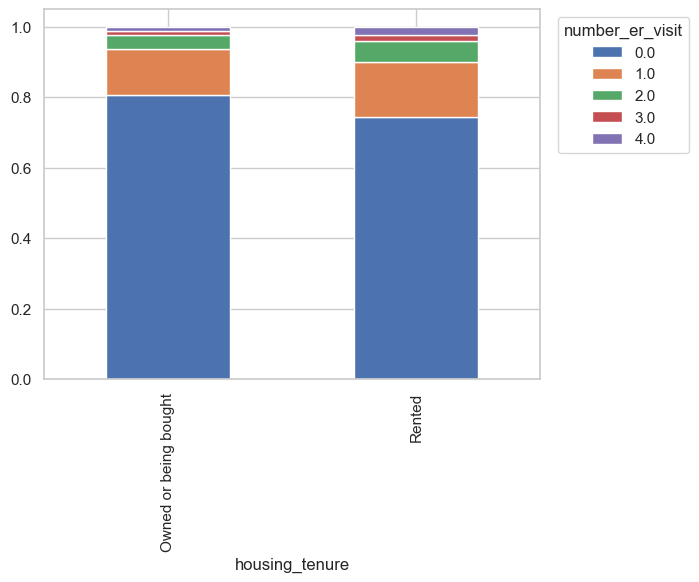

In [36]:
tenure_er_stacked = pd.crosstab(
    data_drop_other['housing_tenure'],
    data_drop_other['any_er_visit'],
    normalize='index'
)

ax=tenure_er_stacked.plot(
    kind='bar',
    stacked=True
)
ax.legend(
    title='number_er_visit',
    bbox_to_anchor=(1.02, 1)
)



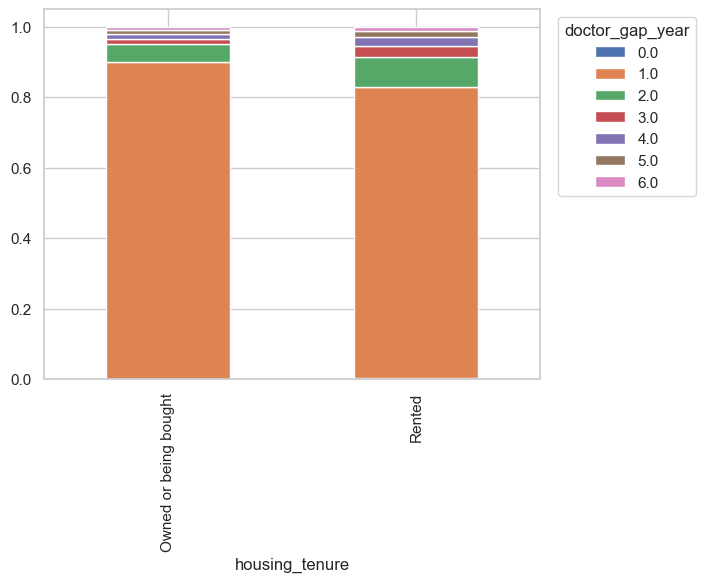

In [37]:
tenure_gap_stacked = pd.crosstab(
    data_drop_other['housing_tenure'],
    data_drop_other['doctor_gap_yr'],
    normalize='index'
)

ax=tenure_gap_stacked.plot(
    kind='bar',
    stacked=True
)
ax.legend(
    title='doctor_gap_year',
    bbox_to_anchor=(1.02, 1)
)


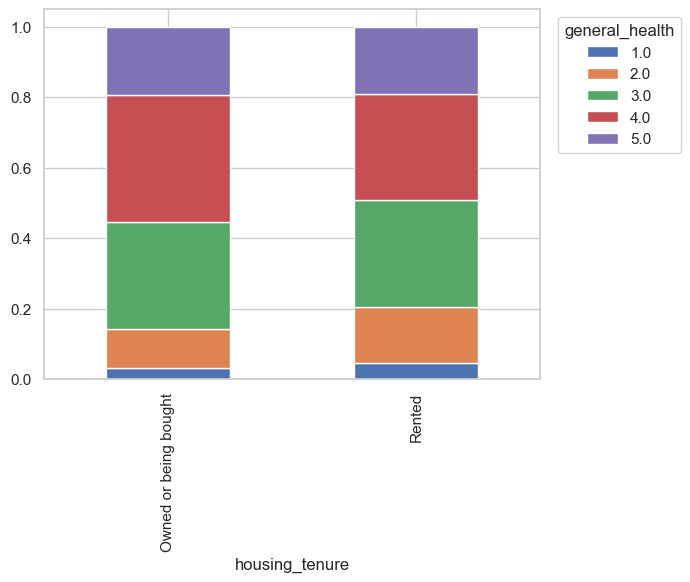

In [38]:
tenure_health_stacked = pd.crosstab(
    data_drop_other['housing_tenure'],
    data_drop_other['general_health'],
    normalize='index'
)

ax=tenure_health_stacked.plot(
    kind='bar',
    stacked=True
)
ax.legend(
    title='general_health',
    bbox_to_anchor=(1.02, 1)
)

In [39]:
chi_square('housing_tenure','usual_place_care',data_drop_other)
chi_square('housing_tenure','delayed_medical_care',data_drop_other)
mann_whitney('housing_tenure','Owned or being bought','Rented','general_health',data_drop_other)
mann_whitney('housing_tenure','Owned or being bought','Rented','any_er_visit',data_drop_other)
mann_whitney('housing_tenure','Owned or being bought','Rented','doctor_gap_yr',data_drop_other)

housing_tenure --- usual_place_care


usual_place_care,Has usual place of care,No single usual place,No usual place
housing_tenure,,,
Owned or being bought,18558,1068,434
Rented,6996,1101,194


Chi square statistics:  529.1569769856063
p_value:  1.2445788523834243e-115
degree of freedom:  2
Cohen W:  0.1366180469065476


housing_tenure --- delayed_medical_care


delayed_medical_care,0.0,1.0
housing_tenure,,
Owned or being bought,18841,1219
Rented,7345,946


Chi square statistics:  235.81124820526725
p_value:  3.2216124473925354e-53
degree of freedom:  1
Cohen W:  0.09120067812829513


housing_tenure --- general_health


,group_1,group_2,U-val,p-val,RBC,group_1_median,group_2_median
0,Owned or being bought,Rented,89169347.0,1.821627e-23,-0.072279,4.0,3.0


housing_tenure --- any_er_visit


,group_1,group_2,U-val,p-val,RBC,group_1_median,group_2_median
0,Owned or being bought,Rented,77716212.5,4.083391e-34,0.065447,0.0,0.0


housing_tenure --- doctor_gap_yr


,group_1,group_2,U-val,p-val,RBC,group_1_median,group_2_median
0,Owned or being bought,Rented,77480824.5,4.109618e-57,0.068278,1.0,1.0


#### Housing tenure and government rent assistance

Because `government_rent_assistance` is only meaningful for renters, we first check how it overlaps with `housing_tenure`. In this cleaned dataset, owners and people in other arrangements are coded as `-1` for rent assistance, while renters are coded as either receiving assistance or not receiving assistance. This means the main comparison should be made within renters instead of across all housing tenure groups.


rent_assistance_status,No assistance,Not applicable,Receives assistance
housing_tenure,,,
Other arrangement,0,566,0
Owned or being bought,0,20060,0
Rented,7071,0,1220


rent_assistance_status,No assistance,Not applicable,Receives assistance
housing_tenure,,,
Other arrangement,0.00,100.0,0.00
Owned or being bought,0.00,100.0,0.00
Rented,85.29,0.0,14.71


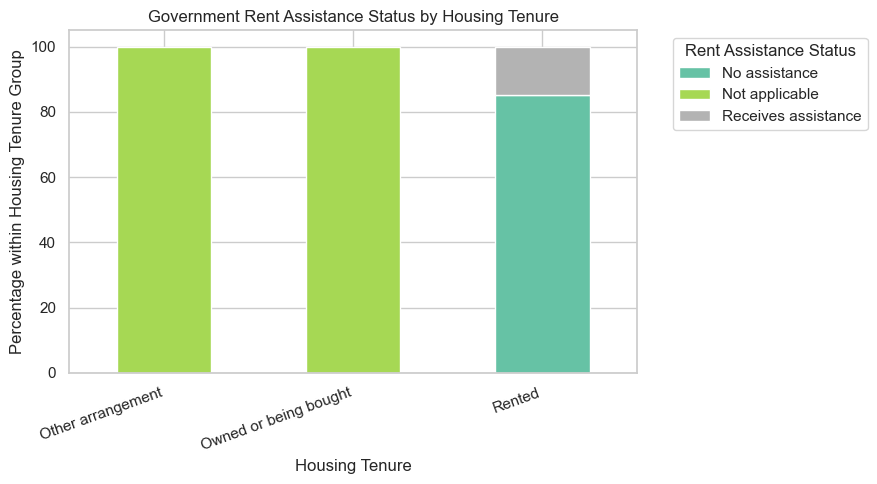

In [40]:
rent_assistance_labels = {
    -1.0: 'Not applicable',
    0.0: 'No assistance',
    1.0: 'Receives assistance'
}

tenure_assist_data = data.copy()
tenure_assist_data['rent_assistance_status'] = tenure_assist_data['government_rent_assistance'].map(rent_assistance_labels)

tenure_assist_counts = pd.crosstab(
    tenure_assist_data['housing_tenure'],
    tenure_assist_data['rent_assistance_status']
)
display(tenure_assist_counts)

tenure_assist_pct = pd.crosstab(
    tenure_assist_data['housing_tenure'],
    tenure_assist_data['rent_assistance_status'],
    normalize='index'
) * 100
display(tenure_assist_pct.round(2))

ax = tenure_assist_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5),
    colormap='Set2'
)
plt.title('Government Rent Assistance Status by Housing Tenure')
plt.xlabel('Housing Tenure')
plt.ylabel('Percentage within Housing Tenure Group')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Rent Assistance Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The cross-tab confirms that government rent assistance is nested inside the renter group: about 85% of renters report no assistance and about 15% report receiving assistance. Since non-renters are coded as not applicable, the next step compares renters with and without assistance on access-to-care and health outcome variables.


,rent_assistance_status,n,delayed_care_rate,housing_cost_trouble_rate,any_er_visit_mean,doctor_gap_mean,general_health_mean
0,No assistance,7071,0.121,0.113,0.369,1.374,3.539
1,Receives assistance,1220,0.072,0.171,0.712,1.164,2.789


/var/folders/12/pvgjgk_x1vxcpht0vyjhdvrw0000gn/T/ipykernel_59982/1150711857.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/12/pvgjgk_x1vxcpht0vyjhdvrw0000gn/T/ipykernel_59982/1150711857.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/12/pvgjgk_x1vxcpht0vyjhdvrw0000gn/T/ipykernel_59982/1150711857.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


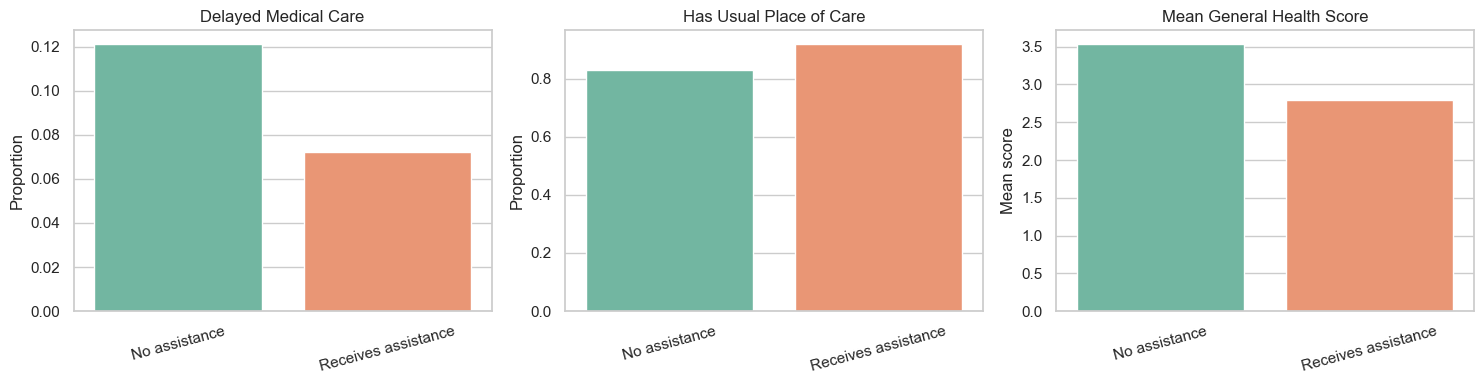

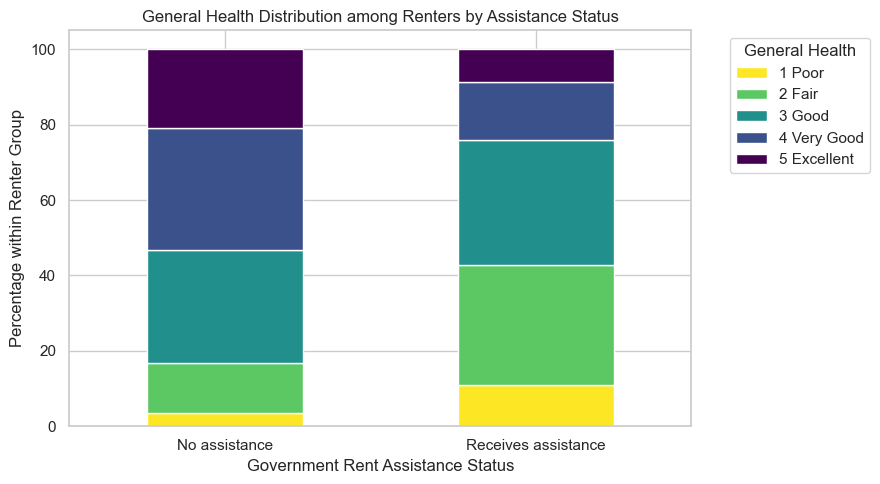

In [41]:
renters = tenure_assist_data[tenure_assist_data['housing_tenure'] == 'Rented'].copy()
renters = renters[renters['rent_assistance_status'].isin(['No assistance', 'Receives assistance'])]

renter_summary = renters.groupby('rent_assistance_status').agg(
    n=('HHX', 'count'),
    delayed_care_rate=('delayed_medical_care', 'mean'),
    housing_cost_trouble_rate=('housing_cost_trouble', 'mean'),
    any_er_visit_mean=('any_er_visit', 'mean'),
    doctor_gap_mean=('doctor_gap_yr', 'mean'),
    general_health_mean=('general_health', 'mean')
).reset_index()

display(renter_summary.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(
    data=renter_summary,
    x='rent_assistance_status',
    y='delayed_care_rate',
    ax=axes[0],
    palette='Set2'
)
axes[0].set_title('Delayed Medical Care')
axes[0].set_xlabel('')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=15)

usual_care_pct = (
    renters.assign(has_usual_place=lambda x: x['usual_place_care'].eq('Has usual place of care'))
    .groupby('rent_assistance_status')['has_usual_place']
    .mean()
    .reset_index()
)
sns.barplot(
    data=usual_care_pct,
    x='rent_assistance_status',
    y='has_usual_place',
    ax=axes[1],
    palette='Set2'
)
axes[1].set_title('Has Usual Place of Care')
axes[1].set_xlabel('')
axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=15)

sns.barplot(
    data=renter_summary,
    x='rent_assistance_status',
    y='general_health_mean',
    ax=axes[2],
    palette='Set2'
)
axes[2].set_title('Mean General Health Score')
axes[2].set_xlabel('')
axes[2].set_ylabel('Mean score')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

health_by_assistance = pd.crosstab(
    renters['rent_assistance_status'],
    renters['general_health'],
    normalize='index'
) * 100
health_by_assistance = health_by_assistance.rename(columns={
    1.0: '1 Poor',
    2.0: '2 Fair',
    3.0: '3 Good',
    4.0: '4 Very Good',
    5.0: '5 Excellent'
})

ax = health_by_assistance.plot(
    kind='bar',
    stacked=True,
    figsize=(9, 5),
    colormap='viridis_r'
)
plt.title('General Health Distribution among Renters by Assistance Status')
plt.xlabel('Government Rent Assistance Status')
plt.ylabel('Percentage within Renter Group')
plt.xticks(rotation=0)
plt.legend(title='General Health', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [42]:
chi_square('rent_assistance_status', 'usual_place_care', renters)
chi_square('rent_assistance_status', 'delayed_medical_care', renters)
chi_square('rent_assistance_status', 'housing_cost_trouble', renters)
mann_whitney('rent_assistance_status', 'No assistance', 'Receives assistance', 'general_health', renters)
mann_whitney('rent_assistance_status', 'No assistance', 'Receives assistance', 'any_er_visit', renters)
mann_whitney('rent_assistance_status', 'No assistance', 'Receives assistance', 'doctor_gap_yr', renters)

rent_assistance_status --- usual_place_care


usual_place_care,Has usual place of care,No single usual place,No usual place
rent_assistance_status,,,
No assistance,5874,1031,166
Receives assistance,1122,70,28


Chi square statistics:  71.03998540418507
p_value:  3.7485488277212844e-16
degree of freedom:  2
Cohen W:  0.0925652491015699


rent_assistance_status --- delayed_medical_care


delayed_medical_care,0.0,1.0
rent_assistance_status,,
No assistance,6213,858
Receives assistance,1132,88


Chi square statistics:  24.442155810963836
p_value:  7.657465181325159e-07
degree of freedom:  1
Cohen W:  0.054295807514586784


rent_assistance_status --- housing_cost_trouble


...

,group_1,group_2,U-val,p-val,RBC,group_1_median,group_2_median
0,No assistance,Receives assistance,5922802.5,3.406256e-103,-0.373146,4.0,3.0


rent_assistance_status --- any_er_visit


,group_1,group_2,U-val,p-val,RBC,group_1_median,group_2_median
0,No assistance,Receives assistance,3595331.5,4.270232e-34,0.166457,0.0,0.0


rent_assistance_status --- doctor_gap_yr


,group_1,group_2,U-val,p-val,RBC,group_1_median,group_2_median
0,No assistance,Receives assistance,4742348.0,3.621398e-17,-0.099468,1.0,1.0


Among renters, government rent assistance appears to separate a more economically vulnerable subgroup from other renters. Renters receiving assistance have a higher rate of housing cost trouble and lower average general health, but they also show a higher probability of having a usual place of care and a lower rate of delayed medical care. This mixed pattern suggests that rent assistance may be associated with both greater baseline need and better connection to support systems, so later modeling should control for demographics, insurance, income ratio, and health status before making any causal interpretation.


delayed_medical_care        0.0        1.0
housing_cost_trouble                      
0.0                   93.638281   6.361719
1.0                   73.312236  26.687764


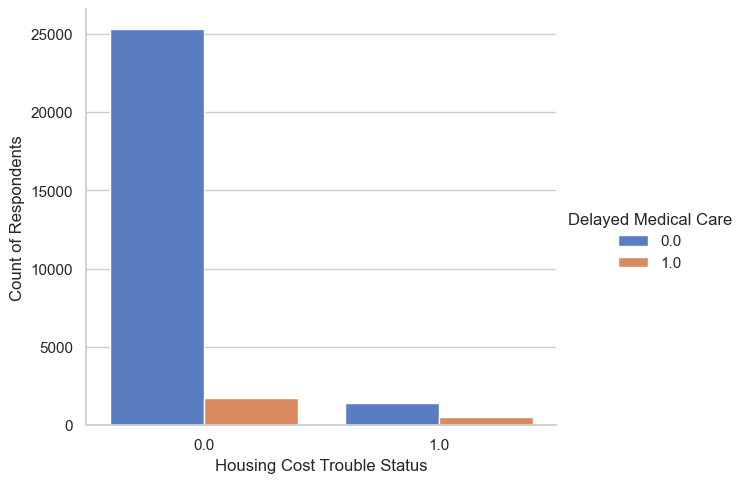

--- Testing Association with: delayed_medical_care ---
Chi-Square Statistic: 1027.7342
p-value: 1.6824e-225
Result: Statistically Significant (p < 0.05). The distributions differ between groups.


Effect Size:
  Cramér's V: 0.1885

Cramér's V interpretation (Cohen's benchmarks):
  → small effect


In [43]:
#housing trouble vs delayed care

print(pd.crosstab(data['housing_cost_trouble'], data['delayed_medical_care'], normalize='index') * 100)
sns.set_theme(style="whitegrid")

# Swapped: x is now the housing predictor, hue is the outcome
g = sns.catplot(
    data=data, 
    x="housing_cost_trouble",     # Groups on the X-axis
    hue="delayed_medical_care",   # Side-by-side comparison bars
    kind="count",
    palette="muted",
    height=5, 
    aspect=1.2
)

g.set_axis_labels("Housing Cost Trouble Status", "Count of Respondents")
g._legend.set_title("Delayed Medical Care")

plt.show()

chi_sq(data, "housing_cost_trouble", "delayed_medical_care")

housing_cost_trouble           0.0        1.0
usual_place_care                             
Has usual place of care  90.344547  86.075949
No single usual place     7.486770  11.075949
No usual place            2.168684   2.848101


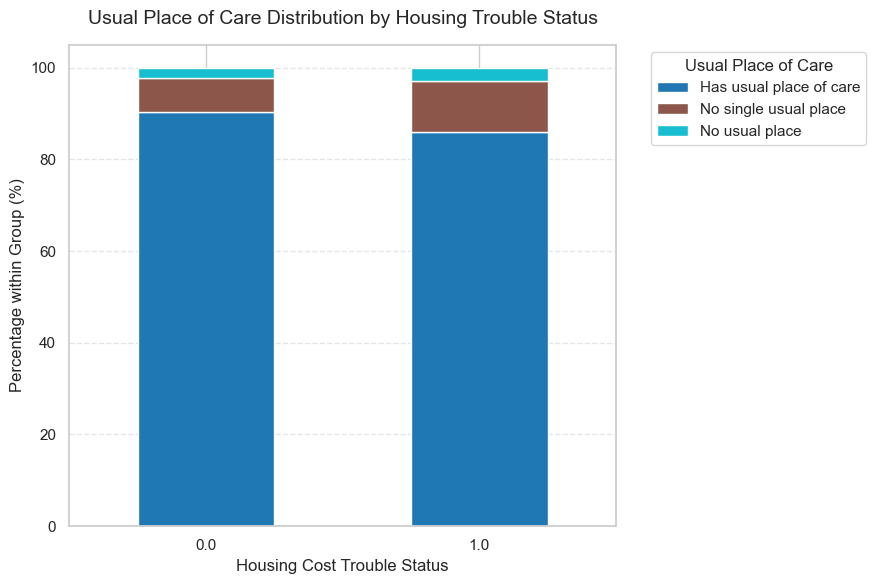

--- Testing Association with: usual_place_care ---
Chi-Square Statistic: 36.8352
p-value: 1.0031e-08
Result: Statistically Significant (p < 0.05). The distributions differ between groups.


Effect Size:
  Cramér's V: 0.0357

Cramér's V interpretation (Cohen's benchmarks):
  → negligible effect


In [44]:
#housing trouble vs place of care

cross_tab = pd.crosstab(
    data['usual_place_care'], 
    data['housing_cost_trouble'], 
    normalize='columns'
) * 100

print(cross_tab)

# 2. Transpose (.T) so the housing groups end up on the X-axis
plot_data = cross_tab.T

# 3. Create the 100% stacked bar chart
# 'stacked=True' stacks the care categories vertically inside each housing bar
ax = plot_data.plot(kind='bar', stacked=True, figsize=(9, 6), width=0.5, colormap='tab10')

# 4. Make the visualization clean and polished
plt.title("Usual Place of Care Distribution by Housing Trouble Status", fontsize=14, pad=15)
plt.xlabel("Housing Cost Trouble Status", fontsize=12)
plt.ylabel("Percentage within Group (%)", fontsize=12)
plt.xticks(rotation=0)  # Keeps 'Yes' and 'No' horizontal and readable

# Move the legend outside the plot box so it doesn't overlap your data
plt.legend(title="Usual Place of Care", bbox_to_anchor=(1.05, 1), loc='upper left')

# Add subtle horizontal gridlines behind the bars for easier reading
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

chi_sq(data, "housing_cost_trouble", 'usual_place_care')

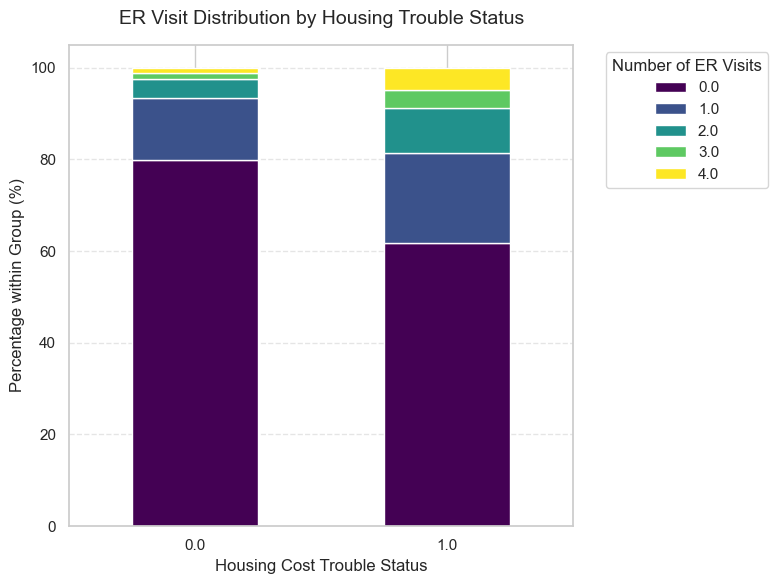

--- Testing Association with: any_er_visit ---
Chi-Square Statistic: 502.8203
p-value: 1.6446e-107
Result: Statistically Significant (p < 0.05). The distributions differ between groups.


Effect Size:
  Cramér's V: 0.1319

Cramér's V interpretation (Cohen's benchmarks):
  → small effect


In [45]:
# Create contingency table
er_counts = pd.crosstab(
    data['housing_cost_trouble'],
    data['any_er_visit'],
    normalize='index'
) * 100

# Plot stacked bar chart
sns.set_theme(style="whitegrid")

ax = er_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    colormap='viridis'
)

# Labels and formatting
plt.title("ER Visit Distribution by Housing Trouble Status", fontsize=14, pad=15)
plt.xlabel("Housing Cost Trouble Status", fontsize=12)
plt.ylabel("Percentage within Group (%)", fontsize=12)

plt.xticks(rotation=0)

# Legend
plt.legend(
    title="Number of ER Visits",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Gridlines
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

chi_sq(data, "housing_cost_trouble", "any_er_visit")

--- Doctor Gap Year Summary Statistics ---
 housing_cost_trouble     Mean  Median  Variance  Max  Total_n
                  0.0 1.245291     1.0  0.662406  6.0    27021
                  1.0 1.311709     1.0  0.780359  6.0     1896


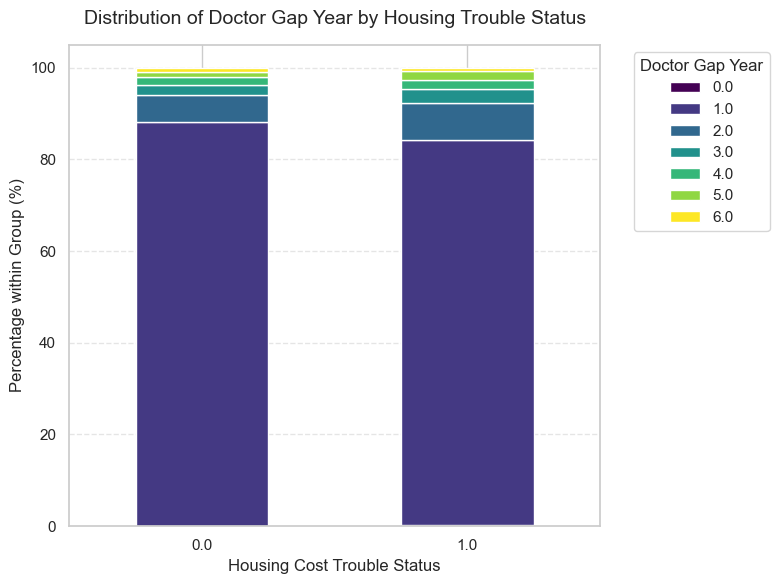

--- Testing Association with: doctor_gap_yr ---
Chi-Square Statistic: 32.7706
p-value: 1.1607e-05
Result: Statistically Significant (p < 0.05). The distributions differ between groups.


Effect Size:
  Cramér's V: 0.0337

Cramér's V interpretation (Cohen's benchmarks):
  → negligible effect


In [46]:
# Housing trouble vs doctor_gap_yr (stacked bar version)

# Summary statistics
doctor_summary = data.groupby('housing_cost_trouble')['doctor_gap_yr'].agg(
    Mean='mean',
    Median='median',
    Variance='var',
    Max='max',
    Total_n='count'
).reset_index()

print("--- Doctor Gap Year Summary Statistics ---")
print(doctor_summary.to_string(index=False))


# Create contingency table
doctor_counts = pd.crosstab(
    data['housing_cost_trouble'],
    data['doctor_gap_yr'],
    normalize='index'
) * 100

# Plot stacked bar chart
sns.set_theme(style="whitegrid")

ax = doctor_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 6),
    colormap='viridis'
)

# Labels and formatting
plt.title("Distribution of Doctor Gap Year by Housing Trouble Status", fontsize=14, pad=15)
plt.xlabel("Housing Cost Trouble Status", fontsize=12)
plt.ylabel("Percentage within Group (%)", fontsize=12)

plt.xticks(rotation=0)

# Legend outside plot
plt.legend(
    title="Doctor Gap Year",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Gridlines
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

chi_sq(data, "housing_cost_trouble", "doctor_gap_yr")

--- General Health Proportions (%) by Housing Status ---
general_health         1.0    2.0    3.0    4.0    5.0
housing_cost_trouble                                  
0.0                   3.27  11.94  30.10  34.93  19.76
1.0                   8.86  23.31  34.34  23.26  10.23

--- Median Health Score (1-5 Scale) ---
Housing Trouble [0.0]: Median Score = 4.0
Housing Trouble [1.0]: Median Score = 3.0


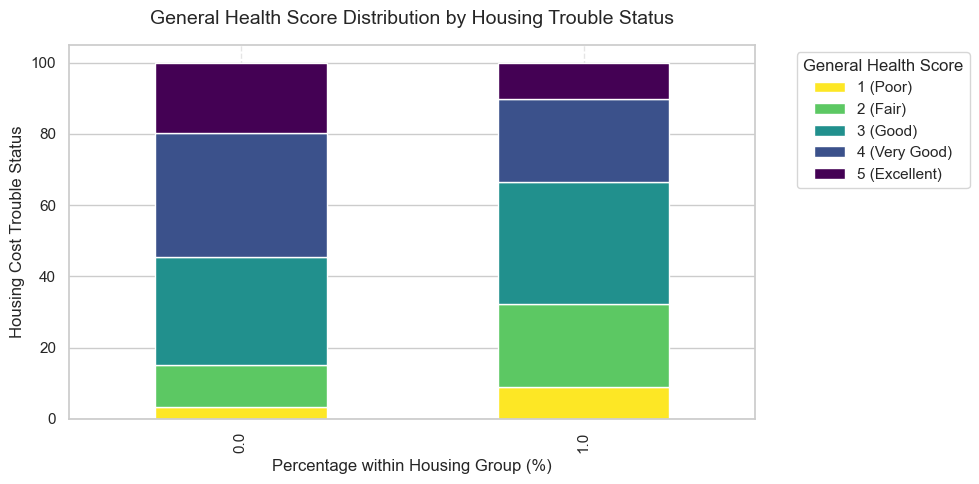

--- Testing Differences in: general_health ---
U Statistic: 1.8705e+07
p-value: 3.6934e-93
Result: Statistically Significant (p < 0.05). The rank distributions of general_health differ.

Group '1': n=1896, median=3.0, mean=3.03
Group '0': n=27021, median=4.0, mean=3.56

Effect Size:
  Rank-biserial r: 2.6980e-01
  → small effect

Interpretation: r = 0.270 means the '1' group tends to
  rank higher on general_health than '0'


In [47]:
# Calculate the percentage breakdown for each numeric rank
health_pct = pd.crosstab(
    data['housing_cost_trouble'], 
    data['general_health'], 
    normalize='index'
) * 100

print("--- General Health Proportions (%) by Housing Status ---")
print(health_pct.round(2))

# Calculate the median score for each group
print("\n--- Median Health Score (1-5 Scale) ---")
medians = data.groupby('housing_cost_trouble')['general_health'].median()
for group, median_val in medians.items():
    print(f"Housing Trouble [{group}]: Median Score = {median_val}")

# 1. Use our numeric cross-tab data

# Optional: Map numeric scores to clear descriptive text for the legend
labels_dict = {1: '1 (Poor)', 2: '2 (Fair)', 3: '3 (Good)', 4: '4 (Very Good)', 5: '5 (Excellent)'}
plot_data = health_pct.rename(columns=labels_dict)

# 2. Create the standard 100% stacked bar chart
# 'stacked=True' stacks them sequentially starting from 0%
ax = plot_data.plot(kind='bar', stacked=True, figsize=(10, 5), width=0.5, colormap='viridis_r')

# 3. Clean up and format
plt.title("General Health Score Distribution by Housing Trouble Status", fontsize=14, pad=15)
plt.xlabel("Percentage within Housing Group (%)", fontsize=12)
plt.ylabel("Housing Cost Trouble Status", fontsize=12)


# Move legend outside the plot box so it doesn't cover your data chunks
plt.legend(title="General Health Score", bbox_to_anchor=(1.05, 1), loc='upper left')

# Add a clean vertical grid to help trace values down to the axis
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

mwu(data, "housing_cost_trouble", "general_health")

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them